## Finite Differenzen Methode in 1D

Das **Randwertproblem**

$$
    y''(x) = f(x), \quad y(0) = y_0, \,\, y(1) = y_N
$$

kann durch Diskretisierung mit Stützstellen

$$
    x_i = \frac{i}{N}, \quad y(x_i) = y_i, \quad (0 \leq i \leq N)
$$

gelöst werden. Damit wird daraus ein Gleichungssystem für die Werte $y_1, \ldots, y_{N-1}$. 

Da die Differentialgleichung **linear** ist, ist das Gleichungssystem ebenfalls linear. Randwertprobleme mit nichtlinearen gDgl können im Prinzip auf dieselbe Art gelöst werden. Dann ist auch das Gleichungssystem nichtlinear und es muss ein weiterer Algorithmus (meist das Newtonverfahren) verwendet werden.

Da die $i$-te Gleichung nur die Variablen $y_{i-1}, y_i, y_{i+1}$ enthält, ist die Matrix des LGS **tridiagonal**. Wenn mehrdimensionale Probleme betrachtet werden, ist die Matrix zwar nicht mehr tridiagonal, hat aber immer noch eine **Bandstruktur** und ist **dünn besetzt**, d.h. die meisten Koeffizienten sind Null.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

 A = 
 [[ 2. -1.  0.  0.  0.]
 [-1.  2. -1.  0.  0.]
 [ 0. -1.  2. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0.  0. -1.  2.]]
b =  [-0.02777778 -0.02777778 -0.02777778 -0.02777778 -0.02777778]


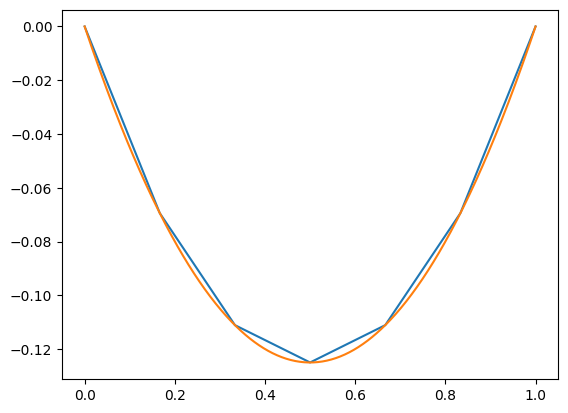

In [4]:
N = 6
h = 1/N
x = np.linspace(0, 1, N+1)  # x0 ... xN hat N+1 Elemente. x0 = 0, xN = 1

f = lambda x: np.ones_like(x) # y'' = f
y0, yN = 0, 0                 # Randwerte

# Tridiagonalmatrix A. Die Matrix hat die Dimension (N-1) x (N-1)
A = 2 * np.diag(np.ones(N-1)) - np.diag( np.ones(N-2), 1) - np.diag( np.ones(N-2), -1)

# rechte Seite b: enthält die Werte f(x[1]) .. f(x[N-1]), sowie die Randwerte im ersten und letzten Eintrag
b = - h**2 * f(x[1:-1])
b[0]  += y0
b[-1] += yN

print(" A = \n", A)
print("b = ", b)

y = np.zeros(N+1)   # gleiche Grösse, wie x 
y[1:-1] = np.linalg.solve(A, b) # Werte y[1] .. y[N-1] werden berechnet --> Thomas Algorithmus verwenden!
y[0] = y0
y[-1] = yN

plt.plot(x, y)
xx = np.linspace(0, 1, 500)
plt.plot(xx, xx * (xx - 1) / 2) # exakte Lösung für y'' = 1, y[0] = 0 = y[1]


## Effizientere Version
Für grosse Matrizen, die fast nur aus Nullen bestehen, ist es ineffizient, die ganze Matrix zu speichern. In unserem Fall ist $A$ eine **Tridiagonalmatrix**. Python bietet den Algorithmus **scipy.linalg.solve_banded** für Matrizen mit Bandstruktur.

In [17]:
from scipy.linalg import solve_banded

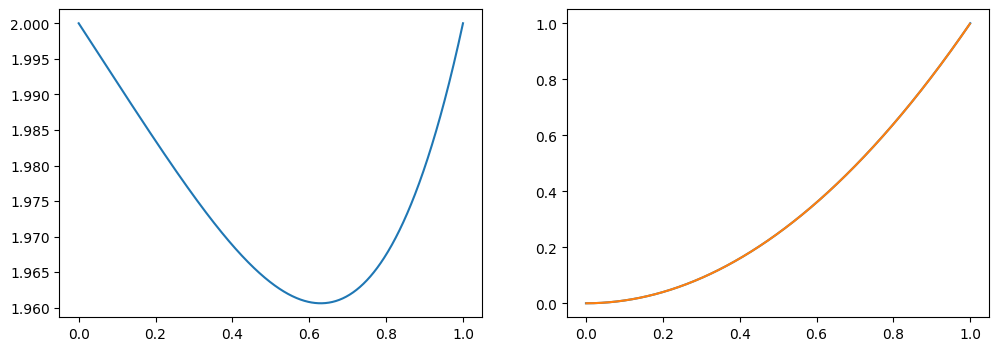

In [23]:
N = 1000
h = 1/N
x = np.linspace(0, 1, N+1)  # x0 ... xN hat N+1 Elemente. x0 = 0, xN = 1

f = lambda x: x**2 # np.ones_like(x) # y'' = f
y0, yN = 2, 2

A = np.zeros( (3, N - 1) ) # Das LGS muss für die inneren Punkte x1 .. x[N-1] gelöst werden 
A[0,1:]  = - np.ones(N-2)
A[1]     = 2*np.ones(N-1)
A[2,:-1] = - np.ones(N-2)

b = - h**2 * f(x[1:-1])
b[0]  += y0
b[-1] += yN

y = np.zeros(N+1)   # gleiche Grösse, wie x 
y[1:-1] = solve_banded((1,1), A, b)
y[0] = y0
y[-1] = yN

fig, ax = plt.subplots(1, 2, figsize = (12, 4))
ax[0].plot(x, y)

ax[1].plot(x, f(x))

d2y = (y[2:] - 2 * y[1:-1] + y[:-2] ) / h**2
ax[1].plot(x[1:-1], d2y)
